Rows in analysis set: 12645145
Rows in full-year subset (2016-2025): 12261365


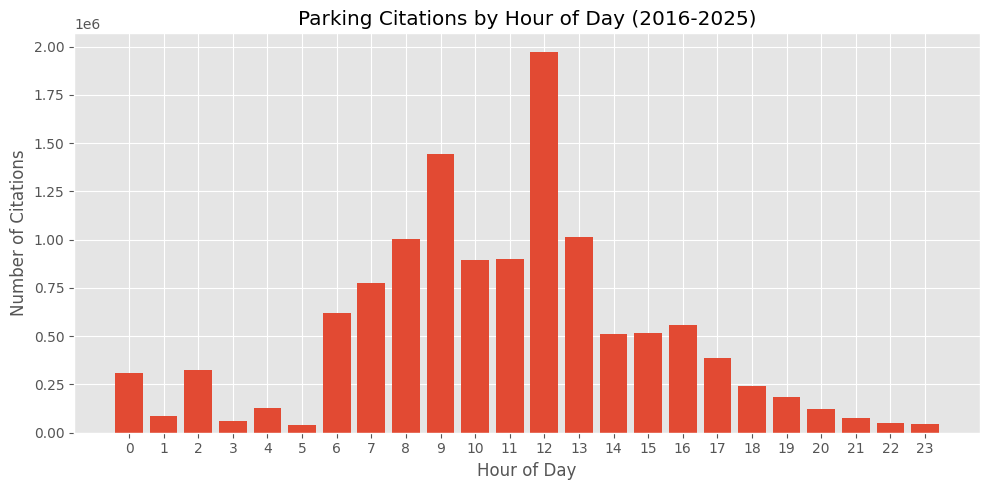

Peak citation hour: 12:00


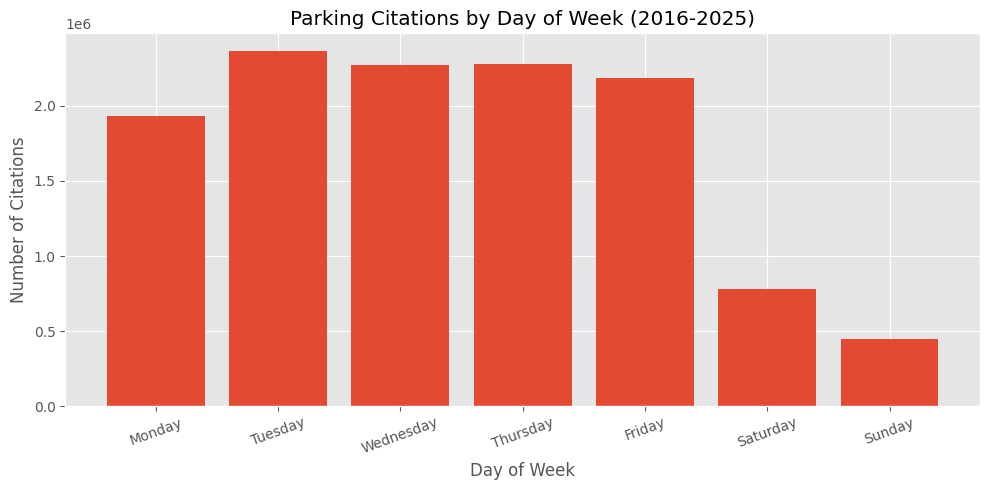

Highest-volume day(s):
day_name
Tuesday      2365872
Thursday     2281976
Wednesday    2270358
dtype: int64


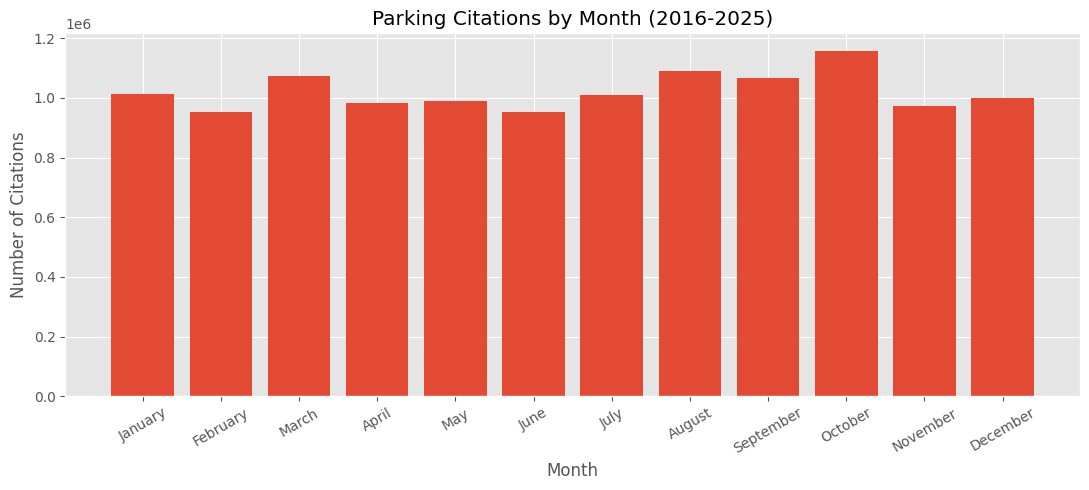

Highest-volume month: October
Lowest-volume month: June


{'peak_hour': '12:00',
 'top_3_days': {'Tuesday': 2365872, 'Thursday': 2281976, 'Wednesday': 2270358},
 'highest_month': 'October',
 'lowest_month': 'June'}

In [ ]:
# ================================
# Arthur's charts for the report
# ================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.style.use("ggplot")

# -------------------------------------------------
# 1) Load data
# Replace the filename with your actual CSV path
# -------------------------------------------------
file_path = r""
df = pd.read_csv(file_path, low_memory=False)

# -------------------------------------------------
# 2) Basic cleaning / preprocessing
# - parse Citation Issued DateTime
# - convert Fine Amount to numeric
# - remove bad datetimes
# - remove duplicate citation numbers
# -------------------------------------------------
df["Citation Issued DateTime"] = pd.to_datetime(
    df["Citation Issued DateTime"],
    errors="coerce"
)

df["Fine Amount"] = pd.to_numeric(df["Fine Amount"], errors="coerce")

# Drop rows missing citation datetime
df = df.dropna(subset=["Citation Issued DateTime"]).copy()

# Remove duplicate citations if the column exists
if "Citation Number" in df.columns:
    df = df.drop_duplicates(subset="Citation Number").copy()

# Derive temporal columns
df["year"] = df["Citation Issued DateTime"].dt.year
df["month_num"] = df["Citation Issued DateTime"].dt.month
df["month_name"] = df["Citation Issued DateTime"].dt.month_name()
df["hour"] = df["Citation Issued DateTime"].dt.hour
df["day_name"] = df["Citation Issued DateTime"].dt.day_name()

df = df[(df["year"] >= 2016) & (df["year"] <= 2026)].copy()
df_full_years = df[df["year"] <= 2025].copy()

print("Rows in analysis set:", len(df))
print("Rows in full-year subset (2016-2025):", len(df_full_years))
# -------------------------------------------------
# Hour of day
# -------------------------------------------------
hour_counts = (
    df_full_years.groupby("hour")
    .size()
    .reindex(range(24), fill_value=0)
)

plt.figure(figsize=(10, 5))
plt.bar(hour_counts.index, hour_counts.values)
plt.title("Parking Citations by Hour of Day (2016-2025)")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Citations")
plt.xticks(range(24))
plt.tight_layout()
plt.show()

peak_hour = hour_counts.idxmax()
print(f"Peak citation hour: {peak_hour}:00")
# -------------------------------------------------
# Week
# -------------------------------------------------
day_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

day_counts = (
    df_full_years.groupby("day_name")
    .size()
    .reindex(day_order)
)

plt.figure(figsize=(10, 5))
plt.bar(day_counts.index, day_counts.values)
plt.title("Parking Citations by Day of Week (2016-2025)")
plt.xlabel("Day of Week")
plt.ylabel("Number of Citations")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

print("Highest-volume day(s):")
print(day_counts.sort_values(ascending=False).head(3))
# -------------------------------------------------
# Month
# -------------------------------------------------
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

month_counts = (
    df_full_years.groupby(["month_num", "month_name"])
    .size()
    .reset_index(name="citations")
    .sort_values("month_num")
)

plt.figure(figsize=(11, 5))
plt.bar(month_counts["month_name"], month_counts["citations"])
plt.title("Parking Citations by Month (2016-2025)")
plt.xlabel("Month")
plt.ylabel("Number of Citations")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

highest_month = month_counts.loc[month_counts["citations"].idxmax(), "month_name"]
lowest_month = month_counts.loc[month_counts["citations"].idxmin(), "month_name"]
print(f"Highest-volume month: {highest_month}")
print(f"Lowest-volume month: {lowest_month}")
# -------------------------------------------------
# Combined summary table
# -------------------------------------------------
time_summary = {
    "peak_hour": f"{hour_counts.idxmax()}:00",
    "top_3_days": day_counts.sort_values(ascending=False).head(3).to_dict(),
    "highest_month": highest_month,
    "lowest_month": lowest_month
}

time_summary
